
# YOLO26s — Cashew Disease Detection

**Experiment gợi ý:** `EXP-Y26S-SMALL-001`

Notebook này dùng để:

- giải nén dataset YOLO26 export từ Roboflow;
- kiểm tra cấu trúc Train / Validation / Test;
- thống kê số ảnh và số bounding box theo từng class;
- huấn luyện `YOLO26s`;
- load checkpoint `best.pt`;
- đánh giá trên **Test set**;
- xuất các chỉ số:
  - Precision
  - Recall
  - F1-score
  - mAP@0.50
  - mAP@0.75
  - mAP@0.50:0.95
  - AP theo từng class
  - Mean IoU / Median IoU của các prediction match đúng
  - TP / FP / FN
  - Thời gian huấn luyện (giây và phút)
- lưu confusion matrix, PR curve, F1 curve và prediction mẫu;
- đóng gói toàn bộ kết quả thành ZIP.

> **Lưu ý nghiên cứu:** Validation dùng để theo dõi/chọn checkpoint. Test chỉ nên dùng để đánh giá cuối cùng, không dùng để chỉnh learning rate, augmentation, epochs hoặc các hyperparameter khác.



## 01. Cài thư viện

Trên Kaggle nên bật GPU tại:

`Settings → Accelerator → GPU`


In [1]:

# ============================================================
# 01. INSTALL ULTRALYTICS
# ============================================================

!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 12.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 5.6 MB/s eta 0:00:00


## 02. Import & kiểm tra môi trường

In [2]:

import os
import sys
import json
import glob
import time
import random
import shutil
import zipfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

MATRIX_CMAP = LinearSegmentedColormap.from_list(
    "readable_blues", ["#ffffff", "#dbeafe", "#93c5fd"]
)
from PIL import Image, ImageDraw

import torch
import yaml
import ultralytics
from ultralytics import YOLO

print("=" * 70)
print("ENVIRONMENT")
print("=" * 70)
print("Python      :", sys.version.split()[0])
print("PyTorch     :", torch.__version__)
print("Ultralytics :", ultralytics.__version__)
print("CUDA        :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
else:
    print("GPU         : Không có GPU - hãy bật GPU trong Kaggle Settings")


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
ENVIRONMENT
Python      : 3.12.13
PyTorch     : 2.10.0+cu128
Ultralytics : 8.4.160
CUDA        : True
GPU         : Tesla T4


## 03. Configuration

In [3]:

# ============================================================
# CONFIG
# ============================================================

EXPERIMENT_ID = "EXP-Y26S-SMALL-007"
SEED = 42

MODEL_NAME = "yolo26s.pt"

EPOCHS = 50
PATIENCE = 20
IMG_SIZE = 640
BATCH_SIZE = 8
WORKERS = 4

OPTIMIZER = "AdamW"
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 5e-4

# Augmentation nhẹ cho dataset nhỏ
MOSAIC = 0.5
MIXUP = 0.0
COPY_PASTE = 0.0
FLIPLR = 0.5

# Threshold chỉ dùng cho custom IoU analysis
PRED_CONF = 0.25
NMS_IOU = 0.70
MATCH_IOU = 0.50

DEVICE = 0 if torch.cuda.is_available() else "cpu"

# Tên file ZIP bạn đã gửi
ZIP_FILENAME = "test.v1-ver01_170_image_09-10-2026.yolo26.zip"

WORK_ROOT = Path("/kaggle/working/cashew_yolo26")
DATASET_DIR = WORK_ROOT / "dataset"
RUNS_DIR = WORK_ROOT / "runs"
EXPORT_DIR = WORK_ROOT / "export"

for p in [WORK_ROOT, RUNS_DIR, EXPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Experiment :", EXPERIMENT_ID)
print("Model      :", MODEL_NAME)
print("Device     :", DEVICE)
print("Image size :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)


Experiment : EXP-Y26S-SMALL-007
Model      : yolo26s.pt
Device     : 0
Image size : 640
Batch size : 8



## 04. Tìm file dataset ZIP trên Kaggle

Notebook sẽ tự tìm file ZIP trong `/kaggle/input/`.

Bạn chỉ cần upload dataset ZIP thành Kaggle Dataset hoặc Add Input vào notebook.


In [4]:
# ============================================================
# 04. FIND YOLO DATASET ON KAGGLE
# ============================================================

import glob
from pathlib import Path

# Tìm data.yaml trong toàn bộ Kaggle Input
yaml_files = (
    glob.glob("/kaggle/input/**/data.yaml", recursive=True)
    + glob.glob("/kaggle/input/**/data.yml", recursive=True)
)

print("Các data.yaml tìm được:")

for p in yaml_files:
    print(" -", p)

if len(yaml_files) == 0:
    raise FileNotFoundError(
        "Không tìm thấy data.yaml trong /kaggle/input/. "
        "Hãy kiểm tra dataset đã được Add Input chưa."
    )

# Nếu chỉ có 1 data.yaml thì tự động chọn
ORIGINAL_YAML = Path(yaml_files[0])

# Folder chứa data.yaml chính là root của dataset YOLO
DATASET_SOURCE_DIR = ORIGINAL_YAML.parent

print("\nDataset root :", DATASET_SOURCE_DIR)
print("data.yaml    :", ORIGINAL_YAML)

Các data.yaml tìm được:
 - /kaggle/input/datasets/kimlonkkk/yolo26-test-v09/Test_400image_V6.v1i.yolo26/data.yaml

Dataset root : /kaggle/input/datasets/kimlonkkk/yolo26-test-v09/Test_400image_V6.v1i.yolo26
data.yaml    : /kaggle/input/datasets/kimlonkkk/yolo26-test-v09/Test_400image_V6.v1i.yolo26/data.yaml


## 05. Giải nén dataset và chuẩn hóa `data.yaml`

In [5]:
# ============================================================
# 05. LOAD & FIX DATA.YAML
# ============================================================

import yaml

with open(ORIGINAL_YAML, "r", encoding="utf-8") as f:
    raw_cfg = yaml.safe_load(f)

print("Original data.yaml:")
print(raw_cfg)

Original data.yaml:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 3, 'names': ['anthracnose', 'leaf_miner', 'red_rust'], 'roboflow': {'workspace': 'nguyen-tien-tai-32hgs', 'project': 'test_400image_v6', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/nguyen-tien-tai-32hgs/test_400image_v6/dataset/1'}}


In [6]:

# ============================================================
# FIX ROBOFLOW PATHS
# ============================================================

yaml_dir = ORIGINAL_YAML.parent.resolve()

def find_split(split):
    candidates = []

    if split == "train":
        raw = raw_cfg.get("train")
        fallback_names = ["train"]
    elif split == "val":
        raw = raw_cfg.get("val")
        fallback_names = ["valid", "val"]
    else:
        raw = raw_cfg.get("test")
        fallback_names = ["test"]

    if raw:
        raw_path = Path(str(raw))
        if raw_path.is_absolute():
            candidates.append(raw_path)
        else:
            candidates.append((yaml_dir / raw_path).resolve())

    for name in fallback_names:
        candidates.append((yaml_dir / name / "images").resolve())
        candidates.append((DATASET_DIR / name / "images").resolve())

    for p in candidates:
        if p.exists():
            return p

    raise FileNotFoundError(f"Không tìm thấy split {split}. Đã thử: {candidates}")

TRAIN_IMAGES = find_split("train")
VAL_IMAGES = find_split("val")
TEST_IMAGES = find_split("test")

fixed_cfg = {
    "train": str(TRAIN_IMAGES),
    "val": str(VAL_IMAGES),
    "test": str(TEST_IMAGES),
    "nc": int(raw_cfg["nc"]),
    "names": raw_cfg["names"],
}

# Lưu trực tiếp vào /kaggle/working/cashew_yolo26/
FIXED_YAML = WORK_ROOT / "data_fixed.yaml"

with open(FIXED_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        fixed_cfg,
        f,
        sort_keys=False,
        allow_unicode=True
    )

print("Fixed YAML :", FIXED_YAML)
print("Train      :", TRAIN_IMAGES)
print("Validation :", VAL_IMAGES)
print("Test       :", TEST_IMAGES)
print("Classes    :", fixed_cfg["names"])

with open(FIXED_YAML, "r", encoding="utf-8") as f:
    print("\n" + f.read())


Fixed YAML : /kaggle/working/cashew_yolo26/data_fixed.yaml
Train      : /kaggle/input/datasets/kimlonkkk/yolo26-test-v09/Test_400image_V6.v1i.yolo26/train/images
Validation : /kaggle/input/datasets/kimlonkkk/yolo26-test-v09/Test_400image_V6.v1i.yolo26/valid/images
Test       : /kaggle/input/datasets/kimlonkkk/yolo26-test-v09/Test_400image_V6.v1i.yolo26/test/images
Classes    : ['anthracnose', 'leaf_miner', 'red_rust']

train: /kaggle/input/datasets/kimlonkkk/yolo26-test-v09/Test_400image_V6.v1i.yolo26/train/images
val: /kaggle/input/datasets/kimlonkkk/yolo26-test-v09/Test_400image_V6.v1i.yolo26/valid/images
test: /kaggle/input/datasets/kimlonkkk/yolo26-test-v09/Test_400image_V6.v1i.yolo26/test/images
nc: 3
names:
- anthracnose
- leaf_miner
- red_rust



## 06. Kiểm tra và thống kê dataset

In [7]:

# ============================================================
# DATASET STATISTICS
# ============================================================

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def get_images(folder):
    return sorted([
        p for p in Path(folder).rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ])

def image_to_label_path(image_path):
    parts = list(image_path.parts)
    for i in range(len(parts) - 1, -1, -1):
        if parts[i] == "images":
            parts[i] = "labels"
            break
    return Path(*parts).with_suffix(".txt")

def split_stats(folder, class_names):
    images = get_images(folder)
    class_boxes = defaultdict(int)
    images_with_labels = 0
    total_boxes = 0

    for img in images:
        label_path = image_to_label_path(img)

        if not label_path.exists():
            continue

        text = label_path.read_text(encoding="utf-8").strip()

        if not text:
            continue

        images_with_labels += 1

        for line in text.splitlines():
            parts = line.split()

            if len(parts) >= 5:
                cls_id = int(float(parts[0]))
                class_boxes[cls_id] += 1
                total_boxes += 1

    row = {
        "images": len(images),
        "images_with_boxes": images_with_labels,
        "boxes": total_boxes,
    }

    for i, name in enumerate(class_names):
        row[name] = class_boxes[i]

    return row

class_names = fixed_cfg["names"]

stats = {
    "train": split_stats(TRAIN_IMAGES, class_names),
    "val": split_stats(VAL_IMAGES, class_names),
    "test": split_stats(TEST_IMAGES, class_names),
}

stats_df = pd.DataFrame(stats).T
display(stats_df)

stats_df.to_csv(EXPORT_DIR / "dataset_statistics.csv", index=True)

with open(EXPORT_DIR / "dataset_statistics.json", "w", encoding="utf-8") as f:
    json.dump(stats, f, indent=2, ensure_ascii=False)


,images,images_with_boxes,boxes,anthracnose,leaf_miner,red_rust
train,496,494,14261,3465,732,10064
val,80,80,2178,676,109,1393
test,39,39,1335,420,91,824



### Kiểm tra nhanh annotation

Cell dưới hiển thị một số ảnh Train cùng bounding box ground-truth để đảm bảo annotation đọc đúng.


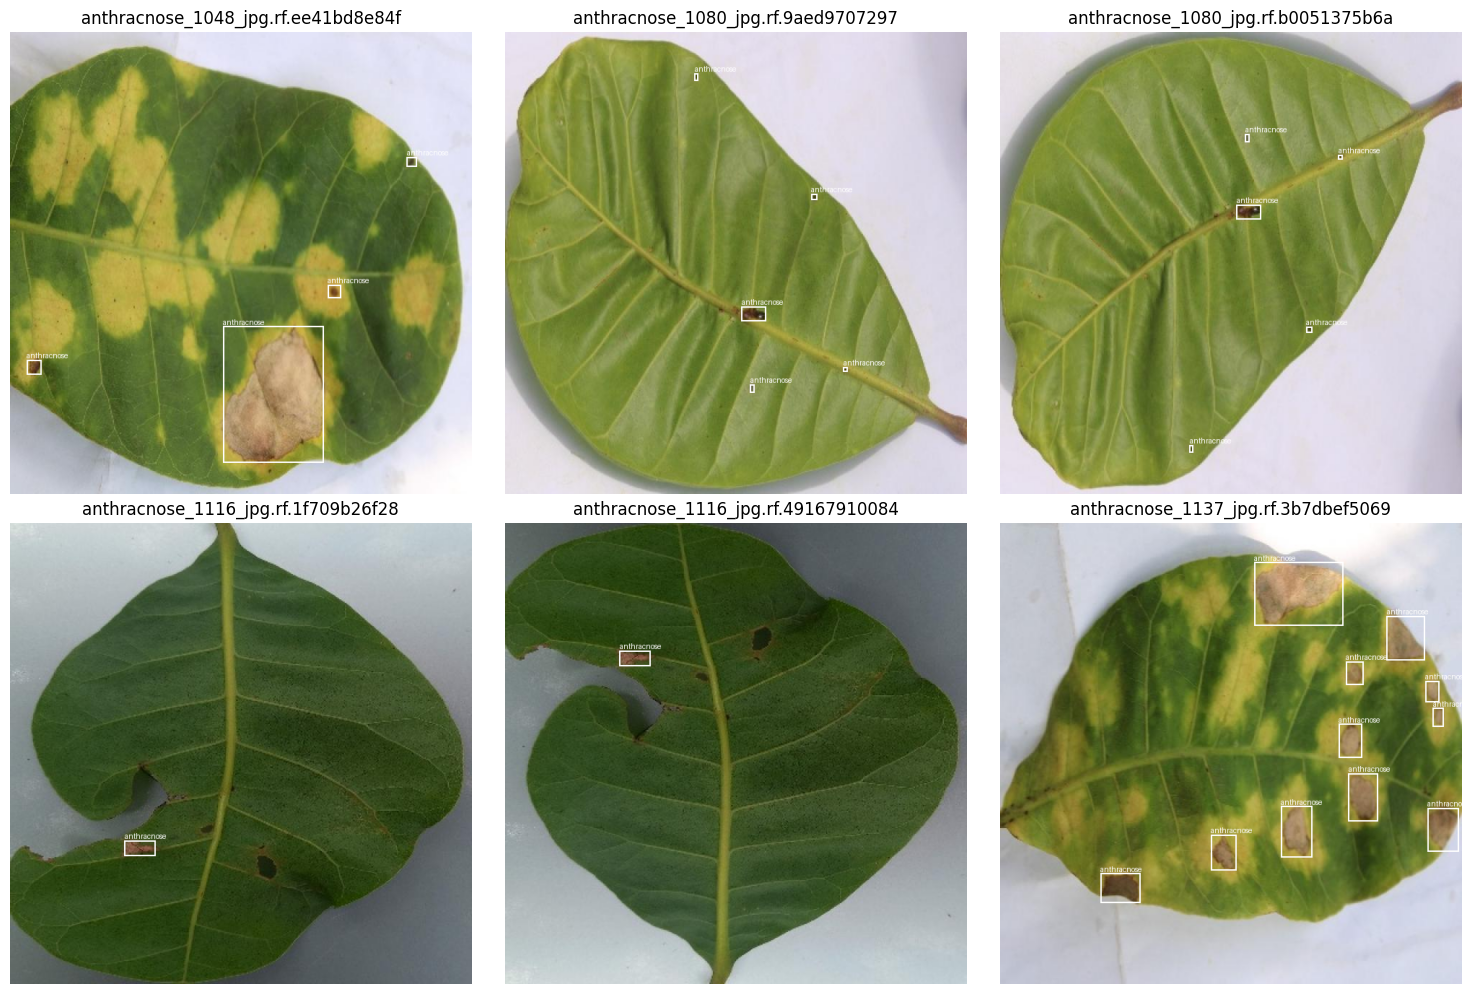

In [8]:

def yolo_xywhn_to_xyxy(xc, yc, w, h, img_w, img_h):
    xc, yc = xc * img_w, yc * img_h
    w, h = w * img_w, h * img_h
    return (
        xc - w / 2,
        yc - h / 2,
        xc + w / 2,
        yc + h / 2
    )

sample_images = get_images(TRAIN_IMAGES)[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for ax, img_path in zip(axes, sample_images):
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    label_path = image_to_label_path(img_path)

    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue

            cls_id = int(float(parts[0]))
            xc, yc, w, h = map(float, parts[1:5])
            box = yolo_xywhn_to_xyxy(xc, yc, w, h, img.width, img.height)

            draw.rectangle(box, width=2)
            draw.text((box[0], max(0, box[1] - 12)), class_names[cls_id])

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.name[:35])

plt.tight_layout()
plt.show()



## 07. Load YOLO26s

Lần chạy baseline đầu tiên giữ nguyên `yolo26s.pt`.

Nếu sau này muốn ablation theo kích thước model, tạo experiment riêng thay vì ghi đè kết quả cũ.


In [9]:

model = YOLO(MODEL_NAME)
print(model)


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_runnin

## 08. Huấn luyện YOLO26s

In [10]:

# ============================================================
# TRAIN
# ============================================================

train_start = time.perf_counter()

train_results = model.train(
    data=str(FIXED_YAML),
    epochs=EPOCHS,
    patience=PATIENCE,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,

    optimizer=OPTIMIZER,
    lr0=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,

    mosaic=MOSAIC,
    mixup=MIXUP,
    copy_paste=COPY_PASTE,
    fliplr=FLIPLR,

    seed=SEED,
    deterministic=True,

    project=str(RUNS_DIR / "train"),
    name=EXPERIMENT_ID,
    exist_ok=True,

    plots=True,
    save=True,
    verbose=True,
)

training_time = time.perf_counter() - train_start

print(f"\nTraining time: {training_time:.1f} seconds ({training_time / 60:.2f} minutes)")


Ultralytics 8.4.160 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cashew_yolo26/data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=EXP-Y26S-SMALL-007, nbs=64, nms

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/50       3.2G      2.138      2.024   0.004089        256        640: 100% ━━━━━━━━━━━━ 62/62 7.4it/s 8.4s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 5.4it/s 0.9s0.2s
                   all         80       2178      0.507      0.536      0.474      0.217

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       3/50       3.2G      2.093      1.822   0.003678        148        640: 100% ━━━━━━━━━━━━ 62/62 7.2it/s 8.6s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 5.8it/s 0.9s0.2s
                   all         80       2178      0.498      0.476      0.454      0.209

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       4/50       3.2G      2.102      1.813   0.003815        200        640: 100% ━━━━━━━━━━━━ 62/62 7.4it/s 8.4s0.1s
                 Class     Images  Instances  

## 09. Xác định `best.pt` và xem learning curves

Best checkpoint: /kaggle/working/cashew_yolo26/runs/train/EXP-Y26S-SMALL-007/weights/best.pt
Last checkpoint: /kaggle/working/cashew_yolo26/runs/train/EXP-Y26S-SMALL-007/weights/last.pt


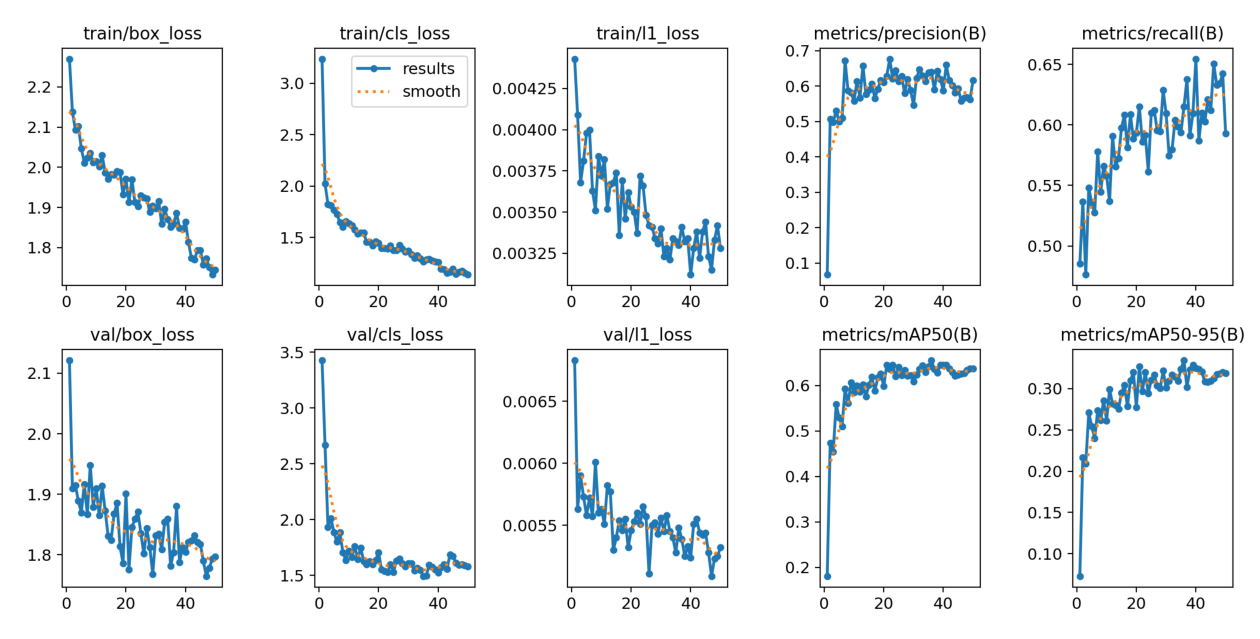

In [11]:

TRAIN_RUN_DIR = RUNS_DIR / "train" / EXPERIMENT_ID
BEST_PT = TRAIN_RUN_DIR / "weights" / "best.pt"
LAST_PT = TRAIN_RUN_DIR / "weights" / "last.pt"

assert BEST_PT.exists(), f"Không tìm thấy {BEST_PT}"

print("Best checkpoint:", BEST_PT)
print("Last checkpoint:", LAST_PT)

results_png = TRAIN_RUN_DIR / "results.png"

if results_png.exists():
    img = Image.open(results_png)
    plt.figure(figsize=(16, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


# Ultralytics stores rows as predicted classes and columns as true classes.
# Render the saved matrices with a light blue/white scale and black labels.
def save_readable_confusion_matrices(metrics, output_dir):
    confusion = getattr(metrics, "confusion_matrix", None)
    if confusion is None:
        raise RuntimeError("Ultralytics did not return a confusion matrix; validate with plots=True.")
    matrix = np.asarray(confusion.matrix, dtype=np.float64)
    labels = [class_names[i] for i in range(len(class_names))]
    if matrix.shape == (len(labels) + 1, len(labels) + 1):
        labels.append("background")
    elif matrix.shape != (len(labels), len(labels)):
        raise ValueError(f"Unexpected confusion matrix shape: {matrix.shape}")

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    for normalized, suffix in ((False, ""), (True, "_normalized")):
        values = matrix / np.maximum(matrix.sum(axis=0, keepdims=True), 1) if normalized else matrix
        pd.DataFrame(values, index=labels, columns=labels).to_csv(
            output_dir / f"confusion_matrix{suffix}.csv"
        )
        fig, ax = plt.subplots(figsize=(10, 8), facecolor="white")
        ax.imshow(values, cmap=MATRIX_CMAP, vmin=0, vmax=1 if normalized else max(float(values.max()), 1))
        ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
        ax.set_yticks(range(len(labels)), labels)
        ax.set_xlabel("True class")
        ax.set_ylabel("Predicted class")
        ax.set_title("Confusion Matrix" + (" Normalized" if normalized else ""))
        for row in range(len(labels)):
            for col in range(len(labels)):
                value = f"{values[row, col]:.2f}" if normalized else f"{int(values[row, col])}"
                ax.text(col, row, value, ha="center", va="center", color="black", fontsize=9)
        fig.tight_layout()
        fig.savefig(output_dir / f"confusion_matrix{suffix}.png", dpi=200, bbox_inches="tight")
        plt.close(fig)


# Re-evaluate the selected checkpoint on Validation, then replace the
# automatically styled train-run matrix figures in the exported archive.
validation_model = YOLO(str(BEST_PT))
validation_metrics = validation_model.val(
    data=str(FIXED_YAML), split="val", imgsz=IMG_SIZE, batch=BATCH_SIZE,
    device=DEVICE, workers=WORKERS, conf=0.001, iou=NMS_IOU,
    plots=True, save_json=False,
    project=str(RUNS_DIR / "validation"), name=EXPERIMENT_ID,
    exist_ok=True, verbose=True,
)
save_readable_confusion_matrices(validation_metrics, RUNS_DIR / "validation" / EXPERIMENT_ID)
save_readable_confusion_matrices(validation_metrics, TRAIN_RUN_DIR)



## 10. Đánh giá checkpoint tốt nhất trên Test set

YOLO tự tính:

- Precision
- Recall
- mAP@0.50
- mAP@0.75
- mAP@0.50:0.95
- AP theo từng class

**Không dùng các kết quả Test này để tuning model.**


In [12]:

# ============================================================
# TEST EVALUATION
# ============================================================

best_model = YOLO(str(BEST_PT))

test_metrics = best_model.val(
    data=str(FIXED_YAML),
    split="test",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    conf=0.001,      # threshold thấp để xây PR curve/mAP
    iou=NMS_IOU,     # NMS IoU, KHÔNG phải mAP IoU threshold
    plots=True,
    save_json=False,
    project=str(RUNS_DIR / "test"),
    name=EXPERIMENT_ID,
    exist_ok=True,
    verbose=True,
)

save_readable_confusion_matrices(test_metrics, RUNS_DIR / "test" / EXPERIMENT_ID)
print("\nTest evaluation completed.")


Ultralytics 8.4.160 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26s summary (fused): 120 layers, 9,466,341 parameters, 0 gradients, 20.8 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 1.4±1.3 ms, read: 9.8±5.4 MB/s, size: 45.6 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/kimlonkkk/yolo26-test-v09/Test_400image_V6.v1i.yolo26/test/labels... 39 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 39/39 420.9it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/kimlonkkk/yolo26-test-v09/Test_400image_V6.v1i.yolo26/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.0it/s 2.5s0.7s
                   all         39       1335      0.695       0.66      0.699      0.352
           anthracnose         30        420      

## 11. Tổng hợp Precision / Recall / F1 / mAP

In [13]:

# ============================================================
# BUILT-IN YOLO METRICS
# ============================================================

box = test_metrics.box

precision = float(box.mp)
recall = float(box.mr)
f1 = 2 * precision * recall / (precision + recall + 1e-12)

map50 = float(box.map50)
map75 = float(box.map75)
map5095 = float(box.map)

print("=" * 70)
print("YOLO TEST METRICS")
print("=" * 70)
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1-score        : {f1:.4f}")
print(f"mAP@0.50        : {map50:.4f}")
print(f"mAP@0.75        : {map75:.4f}")
print(f"mAP@0.50:0.95   : {map5095:.4f}")


YOLO TEST METRICS
Precision       : 0.6945
Recall          : 0.6598
F1-score        : 0.6767
mAP@0.50        : 0.6993
mAP@0.75        : 0.2912
mAP@0.50:0.95   : 0.3517


In [14]:

# ============================================================
# PER-CLASS METRICS
# ============================================================

per_class_rows = []

for class_id, class_name in enumerate(class_names):
    p, r, ap50, ap = box.class_result(class_id)
    class_f1 = 2 * p * r / (p + r + 1e-12)

    per_class_rows.append({
        "class_id": class_id,
        "class_name": class_name,
        "precision": float(p),
        "recall": float(r),
        "f1": float(class_f1),
        "mAP50": float(ap50),
        "mAP50_95": float(ap),
    })

per_class_df = pd.DataFrame(per_class_rows)
display(per_class_df)

per_class_df.to_csv(
    EXPORT_DIR / "per_class_metrics.csv",
    index=False
)


,class_id,class_name,precision,recall,f1,mAP50,mAP50_95
0,0,anthracnose,0.777116,0.522998,0.625222,0.629611,0.251479
1,1,leaf_miner,0.665074,0.802198,0.727228,0.800817,0.487452
2,2,red_rust,0.641391,0.654126,0.647696,0.667601,0.316166



## 12. Custom IoU Analysis

mAP đã sử dụng IoU trong quá trình đánh giá. Tuy nhiên, để báo cáo trực quan thêm khả năng localization, phần này tính:

- Mean IoU của các prediction match đúng;
- Median IoU;
- TP / FP / FN;
- Precision / Recall / F1 tại:
  - confidence = `PRED_CONF`
  - match IoU = `MATCH_IOU`

Quy tắc matching:

1. prediction và ground truth phải cùng class;
2. prediction được xét theo confidence giảm dần;
3. mỗi GT chỉ match tối đa một prediction;
4. IoU phải ≥ `MATCH_IOU`.


In [15]:

# ============================================================
# IOU UTILITIES
# ============================================================

def xywhn_to_xyxy(xc, yc, w, h, img_w, img_h):
    xc *= img_w
    yc *= img_h
    w *= img_w
    h *= img_h

    return np.array([
        xc - w / 2,
        yc - h / 2,
        xc + w / 2,
        yc + h / 2
    ], dtype=np.float32)

def box_iou(box_a, box_b):
    x1 = max(float(box_a[0]), float(box_b[0]))
    y1 = max(float(box_a[1]), float(box_b[1]))
    x2 = min(float(box_a[2]), float(box_b[2]))
    y2 = min(float(box_a[3]), float(box_b[3]))

    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    inter = inter_w * inter_h

    area_a = max(0.0, float(box_a[2] - box_a[0])) * max(0.0, float(box_a[3] - box_a[1]))
    area_b = max(0.0, float(box_b[2] - box_b[0])) * max(0.0, float(box_b[3] - box_b[1]))

    union = area_a + area_b - inter

    return inter / union if union > 0 else 0.0

def load_ground_truth(image_path):
    label_path = image_to_label_path(image_path)

    if not label_path.exists():
        return []

    with Image.open(image_path) as im:
        img_w, img_h = im.size

    text = label_path.read_text(encoding="utf-8").strip()

    if not text:
        return []

    gt = []

    for line in text.splitlines():
        parts = line.split()

        if len(parts) < 5:
            continue

        cls_id = int(float(parts[0]))
        xc, yc, w, h = map(float, parts[1:5])

        gt.append({
            "cls": cls_id,
            "box": xywhn_to_xyxy(xc, yc, w, h, img_w, img_h)
        })

    return gt

def greedy_match(gt, preds, match_iou=0.5):
    used_gt = set()
    matches = []

    preds = sorted(preds, key=lambda x: x["conf"], reverse=True)

    for pred in preds:
        best_iou = -1
        best_idx = None

        for j, target in enumerate(gt):
            if j in used_gt:
                continue

            if pred["cls"] != target["cls"]:
                continue

            iou = box_iou(pred["box"], target["box"])

            if iou > best_iou:
                best_iou = iou
                best_idx = j

        if best_idx is not None and best_iou >= match_iou:
            used_gt.add(best_idx)
            matches.append({
                "cls": pred["cls"],
                "conf": pred["conf"],
                "iou": best_iou
            })

    tp = len(matches)
    fp = len(preds) - tp
    fn = len(gt) - tp

    return matches, tp, fp, fn


In [16]:

# ============================================================
# RUN CUSTOM IOU ANALYSIS
# ============================================================

test_images = get_images(TEST_IMAGES)

prediction_results = best_model.predict(
    source=[str(p) for p in test_images],
    imgsz=IMG_SIZE,
    conf=PRED_CONF,
    iou=NMS_IOU,
    device=DEVICE,
    verbose=False,
)

all_matches = []
per_image_rows = []

total_tp = 0
total_fp = 0
total_fn = 0

per_class_counter = {
    i: {"tp": 0, "fp": 0, "fn": 0, "ious": []}
    for i in range(len(class_names))
}

for image_path, result in zip(test_images, prediction_results):
    gt = load_ground_truth(image_path)

    preds = []

    if result.boxes is not None and len(result.boxes) > 0:
        boxes_xyxy = result.boxes.xyxy.cpu().numpy()
        boxes_cls = result.boxes.cls.cpu().numpy().astype(int)
        boxes_conf = result.boxes.conf.cpu().numpy()

        for box_xyxy, cls_id, conf in zip(boxes_xyxy, boxes_cls, boxes_conf):
            preds.append({
                "cls": int(cls_id),
                "conf": float(conf),
                "box": box_xyxy.astype(np.float32)
            })

    matches, tp, fp, fn = greedy_match(
        gt,
        preds,
        match_iou=MATCH_IOU
    )

    total_tp += tp
    total_fp += fp
    total_fn += fn
    all_matches.extend(matches)

    # per-class
    for class_id in range(len(class_names)):
        gt_c = [g for g in gt if g["cls"] == class_id]
        pred_c = [p for p in preds if p["cls"] == class_id]

        m_c, tp_c, fp_c, fn_c = greedy_match(
            gt_c,
            pred_c,
            match_iou=MATCH_IOU
        )

        per_class_counter[class_id]["tp"] += tp_c
        per_class_counter[class_id]["fp"] += fp_c
        per_class_counter[class_id]["fn"] += fn_c
        per_class_counter[class_id]["ious"].extend([x["iou"] for x in m_c])

    image_ious = [m["iou"] for m in matches]

    per_image_rows.append({
        "image": image_path.name,
        "gt_boxes": len(gt),
        "pred_boxes": len(preds),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "mean_matched_iou": float(np.mean(image_ious)) if image_ious else np.nan,
    })

all_ious = [m["iou"] for m in all_matches]

custom_precision = total_tp / (total_tp + total_fp + 1e-12)
custom_recall = total_tp / (total_tp + total_fn + 1e-12)
custom_f1 = 2 * custom_precision * custom_recall / (
    custom_precision + custom_recall + 1e-12
)

mean_iou = float(np.mean(all_ious)) if all_ious else 0.0
median_iou = float(np.median(all_ious)) if all_ious else 0.0

print("=" * 70)
print("CUSTOM IOU ANALYSIS")
print("=" * 70)
print(f"Confidence threshold : {PRED_CONF}")
print(f"Match IoU threshold  : {MATCH_IOU}")
print()
print(f"TP                   : {total_tp}")
print(f"FP                   : {total_fp}")
print(f"FN                   : {total_fn}")
print()
print(f"Precision            : {custom_precision:.4f}")
print(f"Recall               : {custom_recall:.4f}")
print(f"F1-score             : {custom_f1:.4f}")
print(f"Mean IoU (TP)        : {mean_iou:.4f}")
print(f"Median IoU (TP)      : {median_iou:.4f}")


CUSTOM IOU ANALYSIS
Confidence threshold : 0.25
Match IoU threshold  : 0.5

TP                   : 825
FP                   : 389
FN                   : 510

Precision            : 0.6796
Recall               : 0.6180
F1-score             : 0.6473
Mean IoU (TP)        : 0.7471
Median IoU (TP)      : 0.7549


In [17]:

# ============================================================
# PER-CLASS CUSTOM IOU
# ============================================================

custom_class_rows = []

for class_id, class_name in enumerate(class_names):
    d = per_class_counter[class_id]

    tp = d["tp"]
    fp = d["fp"]
    fn = d["fn"]

    p = tp / (tp + fp + 1e-12)
    r = tp / (tp + fn + 1e-12)
    f1_c = 2 * p * r / (p + r + 1e-12)

    custom_class_rows.append({
        "class_id": class_id,
        "class_name": class_name,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": p,
        "recall": r,
        "f1": f1_c,
        "mean_iou_tp": float(np.mean(d["ious"])) if d["ious"] else 0.0,
        "median_iou_tp": float(np.median(d["ious"])) if d["ious"] else 0.0,
    })

custom_class_df = pd.DataFrame(custom_class_rows)
display(custom_class_df)

custom_class_df.to_csv(
    EXPORT_DIR / "custom_iou_per_class.csv",
    index=False
)

per_image_df = pd.DataFrame(per_image_rows)
per_image_df.to_csv(
    EXPORT_DIR / "custom_iou_per_image.csv",
    index=False
)


,class_id,class_name,tp,fp,fn,precision,recall,f1,mean_iou_tp,median_iou_tp
0,0,anthracnose,227,64,193,0.780069,0.540476,0.638537,0.726993,0.729096
1,1,leaf_miner,69,31,22,0.690000,0.758242,0.722513,0.813549,0.863038
2,2,red_rust,529,294,295,0.642770,0.641990,0.642380,0.747028,0.760887


## 13. Xem các biểu đồ đánh giá YOLO

confusion_matrix.png


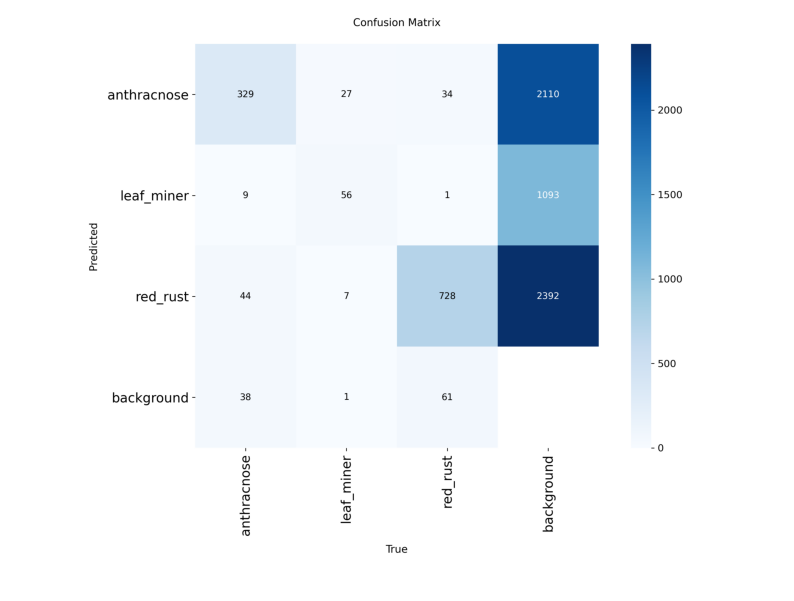

confusion_matrix_normalized.png


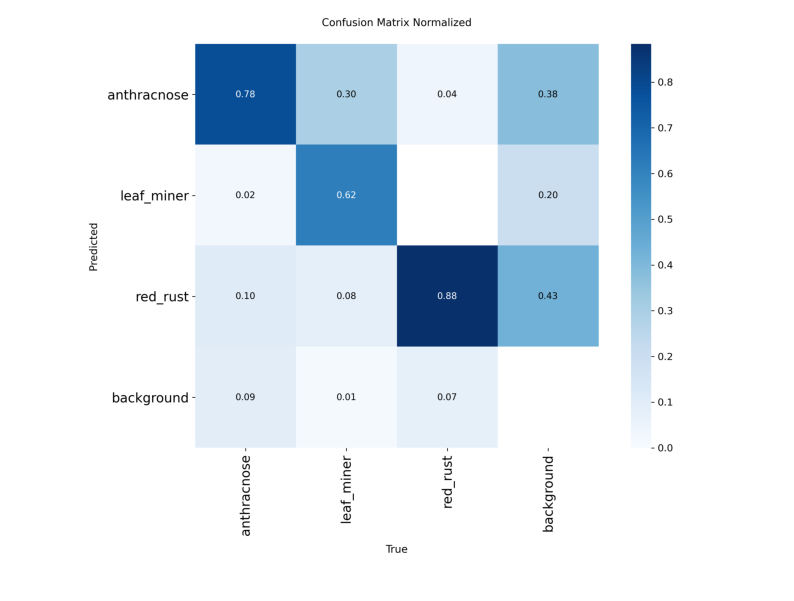

BoxPR_curve.png


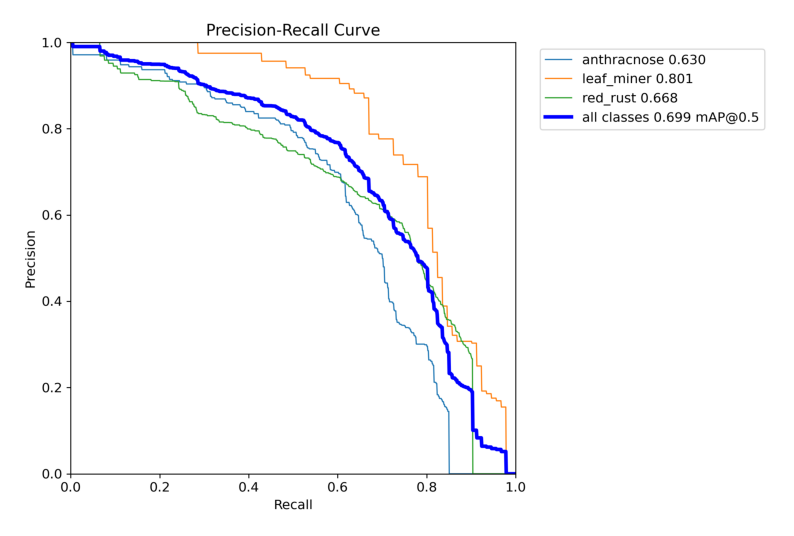

BoxF1_curve.png


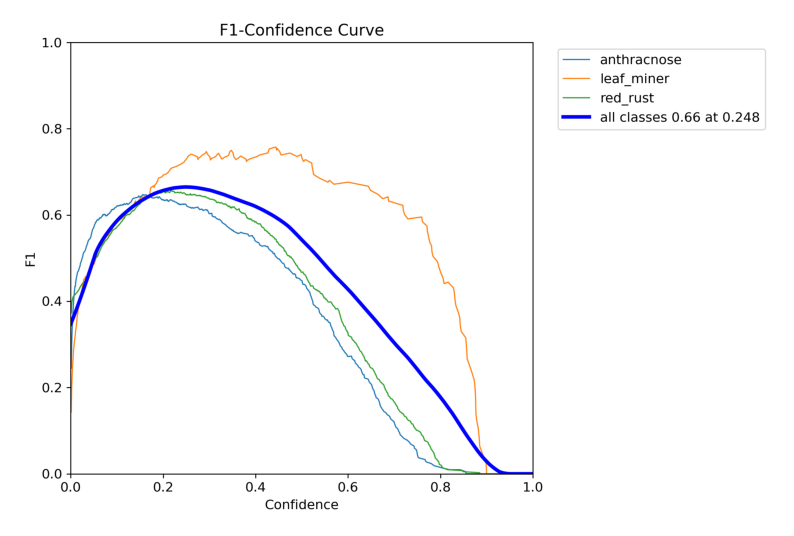

BoxP_curve.png


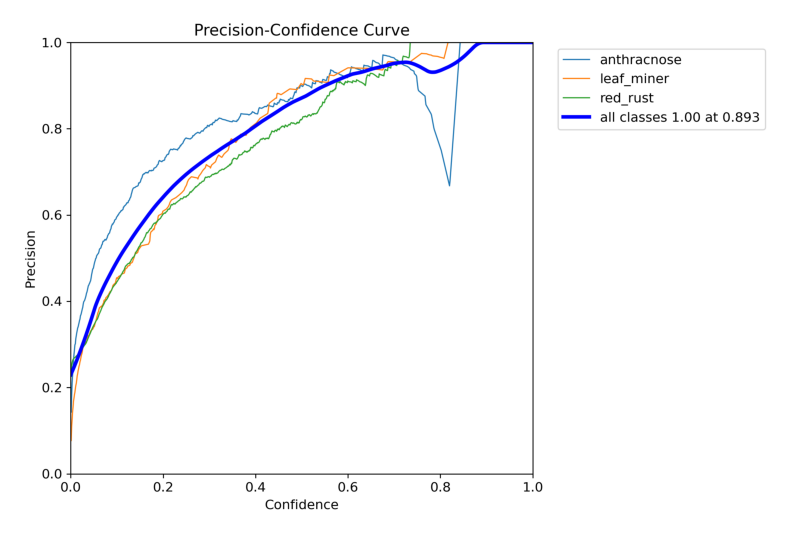

BoxR_curve.png


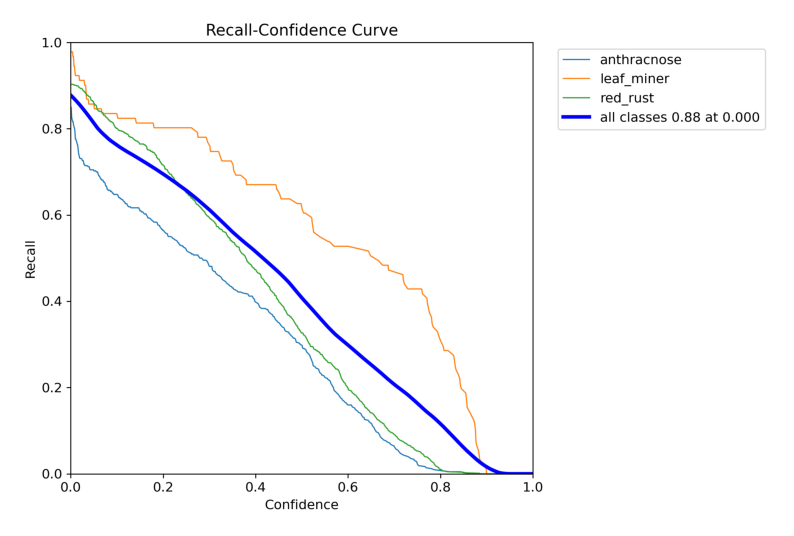

In [18]:

TEST_RUN_DIR = RUNS_DIR / "test" / EXPERIMENT_ID

plot_candidates = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
]

for filename in plot_candidates:
    p = TEST_RUN_DIR / filename

    if p.exists():
        print(filename)
        img = Image.open(p)

        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis("off")
        plt.show()


## 14. Prediction mẫu trên Test set

Results saved to /kaggle/working/cashew_yolo26/export/sample_predictions/predictions


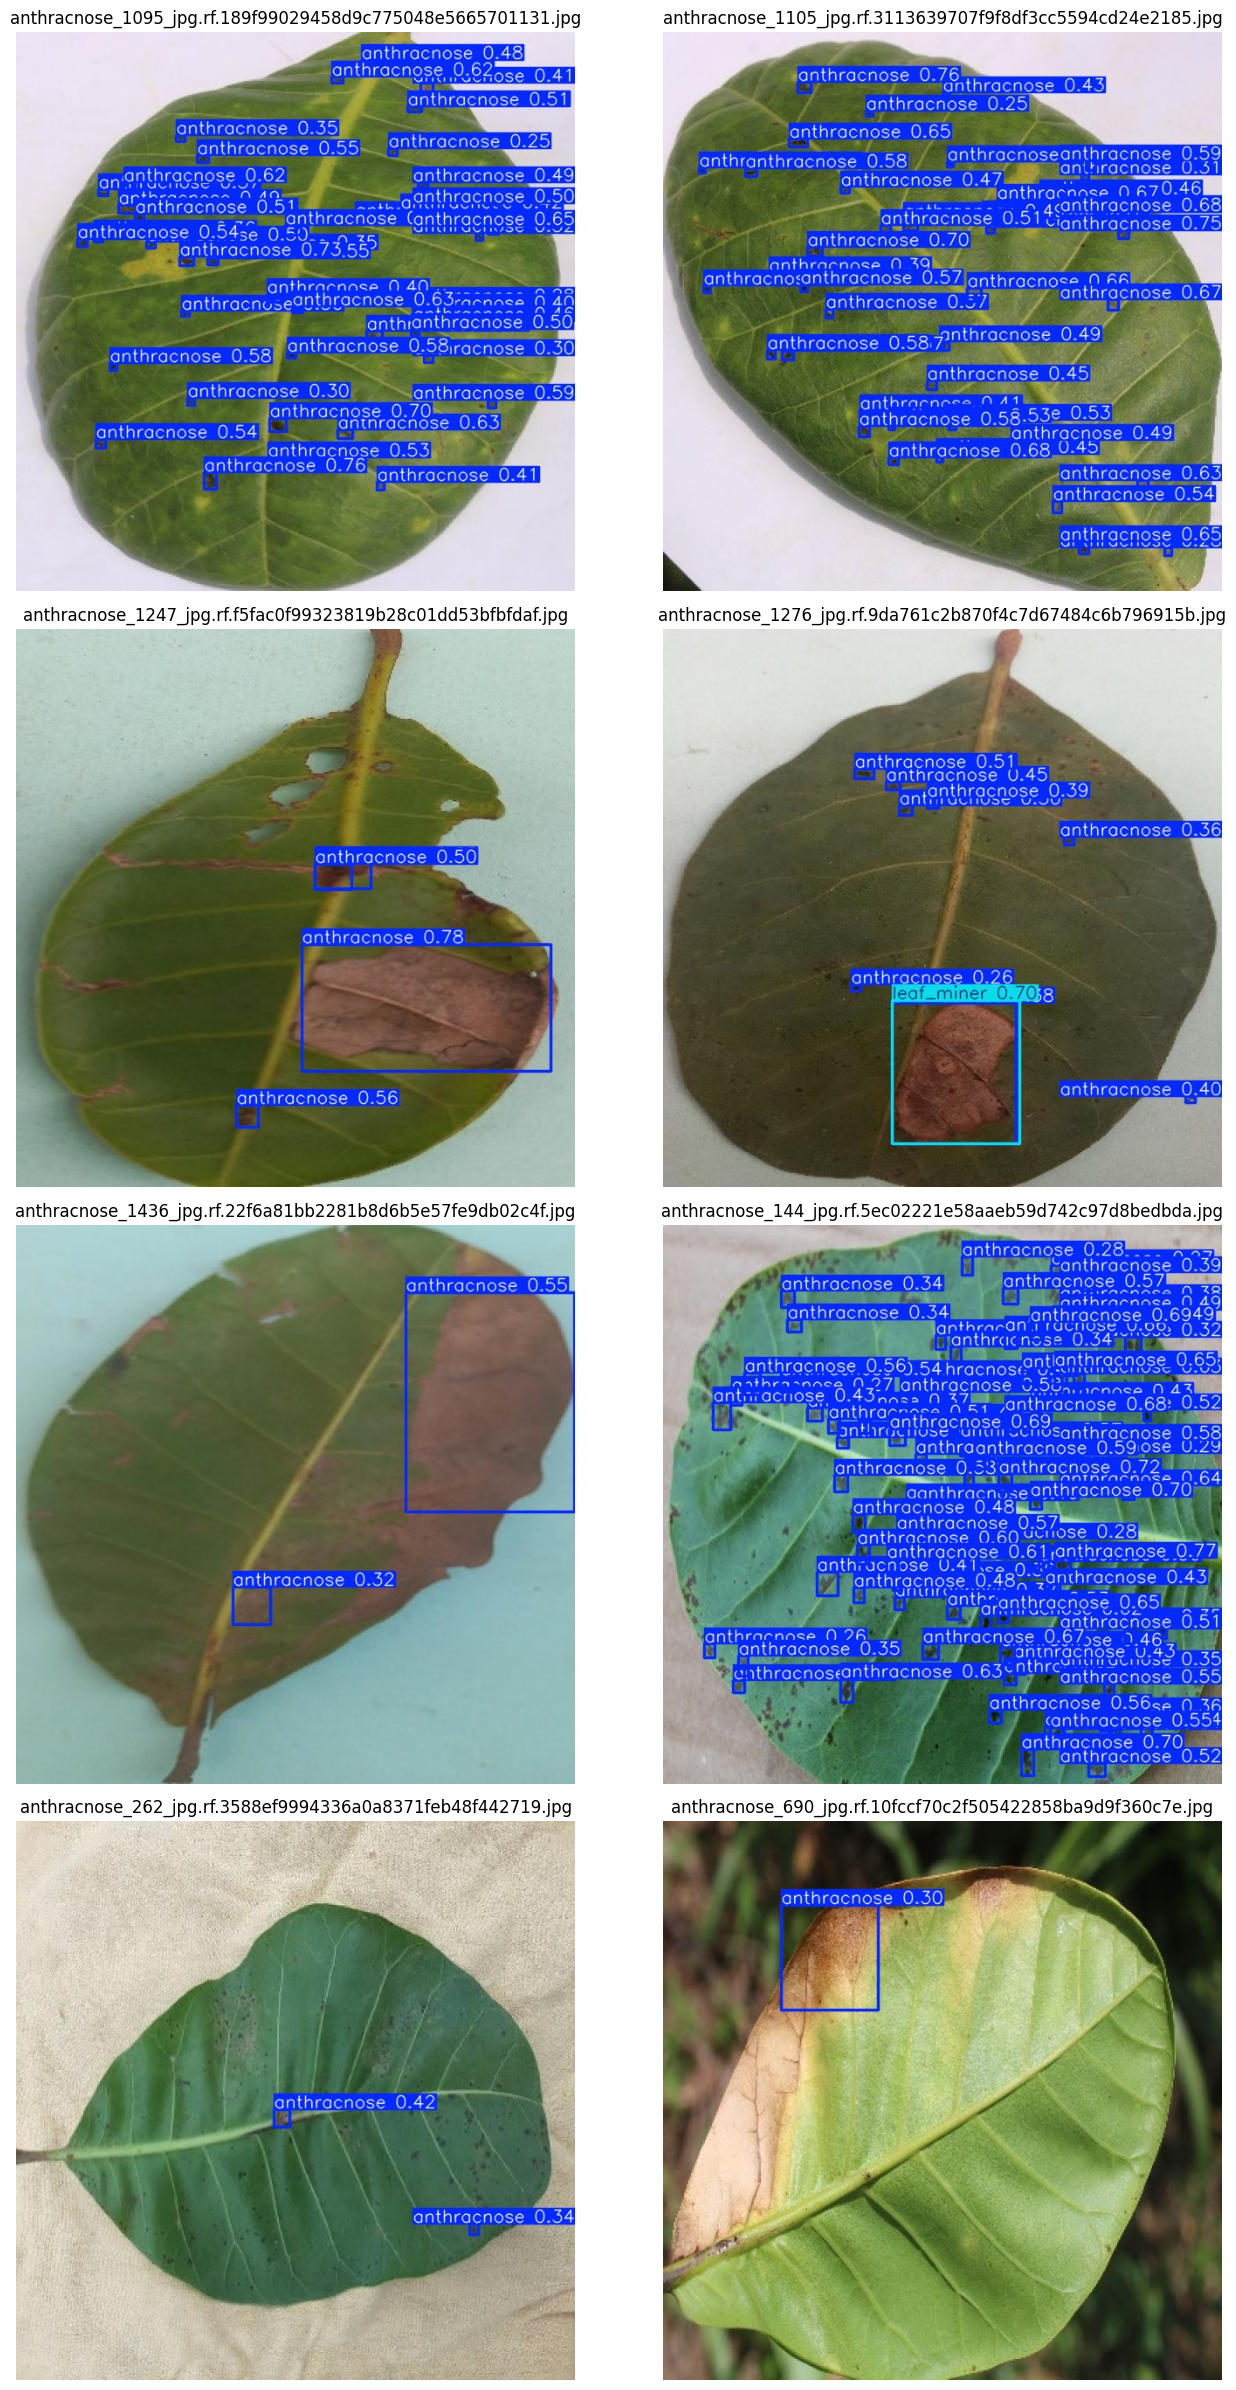

In [19]:

SAMPLE_PRED_DIR = EXPORT_DIR / "sample_predictions"
SAMPLE_PRED_DIR.mkdir(parents=True, exist_ok=True)

sample_source = [str(p) for p in test_images[:min(8, len(test_images))]]

_ = best_model.predict(
    source=sample_source,
    imgsz=IMG_SIZE,
    conf=PRED_CONF,
    iou=NMS_IOU,
    device=DEVICE,
    save=True,
    project=str(SAMPLE_PRED_DIR),
    name="predictions",
    exist_ok=True,
    verbose=False,
)

pred_folder = SAMPLE_PRED_DIR / "predictions"

pred_imgs = get_images(pred_folder)

if pred_imgs:
    cols = 2
    rows = int(np.ceil(len(pred_imgs) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(14, 6 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, p in zip(axes, pred_imgs):
        ax.imshow(Image.open(p))
        ax.set_title(p.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy prediction images.")


## 15. Lưu metrics và experiment config

In [20]:

# ============================================================
# SAVE FINAL METRICS
# ============================================================

metrics_summary = {
    "experiment": {
        "experiment_id": EXPERIMENT_ID,
        "model": MODEL_NAME,
        "seed": SEED,
    },
    "training_config": {
        "epochs": EPOCHS,
        "patience": PATIENCE,
        "imgsz": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "optimizer": OPTIMIZER,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "mosaic": MOSAIC,
        "mixup": MIXUP,
        "copy_paste": COPY_PASTE,
        "fliplr": FLIPLR,
    },
    "dataset": {
        "classes": class_names,
        "statistics": stats,
    },
    "test_yolo_metrics": {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mAP50": map50,
        "mAP75": map75,
        "mAP50_95": map5095,
    },
    "custom_iou_analysis": {
        "prediction_confidence_threshold": PRED_CONF,
        "nms_iou": NMS_IOU,
        "matching_iou_threshold": MATCH_IOU,
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "precision": custom_precision,
        "recall": custom_recall,
        "f1": custom_f1,
        "mean_iou_tp": mean_iou,
        "median_iou_tp": median_iou,
    },
    "efficiency": {
        "training_time_seconds": training_time
    }
}

with open(
    EXPORT_DIR / "metrics_summary.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)

config_summary = {
    "experiment_id": EXPERIMENT_ID,
    "model": MODEL_NAME,
    "seed": SEED,
    "epochs": EPOCHS,
    "patience": PATIENCE,
    "imgsz": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "optimizer": OPTIMIZER,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "mosaic": MOSAIC,
    "mixup": MIXUP,
    "copy_paste": COPY_PASTE,
    "fliplr": FLIPLR,
    "pred_conf": PRED_CONF,
    "nms_iou": NMS_IOU,
    "match_iou": MATCH_IOU,
}

with open(
    EXPORT_DIR / "experiment_config.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(config_summary, f, indent=2, ensure_ascii=False)

print("Saved:", EXPORT_DIR)


Saved: /kaggle/working/cashew_yolo26/export


## 16. Bảng kết quả cuối

In [21]:

summary_df = pd.DataFrame([
    ["Training time (seconds)", training_time],
    ["Training time (minutes)", training_time / 60],
    ["Precision", precision],
    ["Recall", recall],
    ["F1-score", f1],
    ["mAP@0.50", map50],
    ["mAP@0.75", map75],
    ["mAP@0.50:0.95", map5095],
    ["Mean IoU (matched TP)", mean_iou],
    ["Median IoU (matched TP)", median_iou],
    ["Custom Precision @ IoU 0.50", custom_precision],
    ["Custom Recall @ IoU 0.50", custom_recall],
    ["Custom F1 @ IoU 0.50", custom_f1],
], columns=["Metric", "Value"])

display(summary_df)

summary_df.to_csv(
    EXPORT_DIR / "final_summary.csv",
    index=False
)


,Metric,Value
0,Precision,0.694527
1,Recall,0.659774
2,F1-score,0.676704
3,mAP@0.50,0.699343
4,mAP@0.75,0.291239
5,mAP@0.50:0.95,0.351699
6,Mean IoU (matched TP),0.747079
7,Median IoU (matched TP),0.754873
8,Custom Precision @ IoU 0.50,0.679572
9,Custom Recall @ IoU 0.50,0.617978



## 17. Export toàn bộ experiment

ZIP sẽ gồm:

- `best.pt`
- `last.pt`
- training plots
- test plots
- confusion matrices
- PR/F1/P/R curves
- dataset statistics
- per-class metrics
- custom IoU metrics
- prediction samples
- config JSON
- final summary


In [22]:

# Copy checkpoints vào export để dễ lấy
checkpoint_dir = EXPORT_DIR / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

if BEST_PT.exists():
    shutil.copy2(BEST_PT, checkpoint_dir / f"{EXPERIMENT_ID}_best.pt")

if LAST_PT.exists():
    shutil.copy2(LAST_PT, checkpoint_dir / f"{EXPERIMENT_ID}_last.pt")

# Copy plots/logs của train và test
if TRAIN_RUN_DIR.exists():
    shutil.copytree(
        TRAIN_RUN_DIR,
        EXPORT_DIR / "train_run",
        dirs_exist_ok=True
    )

if TEST_RUN_DIR.exists():
    shutil.copytree(
        TEST_RUN_DIR,
        EXPORT_DIR / "test_run",
        dirs_exist_ok=True
    )

ZIP_EXPORT = shutil.make_archive(
    str(WORK_ROOT / EXPERIMENT_ID),
    "zip",
    root_dir=EXPORT_DIR
)

print("=" * 70)
print("DONE")
print("=" * 70)
print("Experiment folder :", EXPORT_DIR)
print("ZIP result        :", ZIP_EXPORT)
print("Best model        :", checkpoint_dir / f"{EXPERIMENT_ID}_best.pt")


DONE
Experiment folder : /kaggle/working/cashew_yolo26/export
ZIP result        : /kaggle/working/cashew_yolo26/EXP-Y26S-SMALL-007.zip
Best model        : /kaggle/working/cashew_yolo26/export/checkpoints/EXP-Y26S-SMALL-007_best.pt



# Cách đọc kết quả

Trong khóa luận, với YOLO Detection nên ưu tiên báo cáo:

| Metric | Vai trò |
|---|---|
| Precision | Prediction bệnh có bao nhiêu phần đúng |
| Recall | Có phát hiện được phần lớn lesion thật hay không |
| mAP@0.50 | Khả năng detection ở IoU 0.5 |
| **mAP@0.50:0.95** | Metric chính, nghiêm ngặt hơn |
| AP per class | Kiểm tra class yếu, đặc biệt khi mất cân bằng |
| Mean IoU | Mức độ khớp vị trí box dự đoán với GT |
| Confusion Matrix | Xem class nào bị nhầm |
| PR/F1 curves | Phân tích threshold confidence |

Đối với dataset nhỏ, **không nên kết luận chỉ từ mAP tổng**. Hãy kiểm tra riêng `anthracnose`, `leaf_miner`, `red_rust`, đặc biệt class có ít annotation.
